# 🏙️ Urban Flexibility Object Detection — Google Street View × GroundingDINO
# ✅ Versione con Checkpoint / Resume per 18.000+ immagini

---

## Sistema di protezione anti-crash

Questo notebook include un sistema completo di **checkpoint e resume** pensato per
elaborazioni lunghe (10.000–20.000 immagini) su Google Colab.

### Come funziona
- Ogni **100 PANO ID** (~400 immagini) i risultati vengono salvati su Drive in un file JSON di checkpoint
- L'Excel viene aggiornato su Drive ad ogni checkpoint (non solo alla fine)
- Se il runtime crasha o viene disconnesso, alla ripresa il notebook **legge il checkpoint** e riparte esattamente da dove si era fermato
- Le immagini già annotate vengono **skippate** (controllo `os.path.exists`) senza rielaborarle
- Un thread **keep-alive** in background previene la disconnessione per inattività

### Cosa fare in caso di crash
1. Riconnetti il runtime Colab
2. Riesegui **tutte le celle nell'ordine** (il setup è necessario ogni volta)
3. La Cella 7 troverà automaticamente il checkpoint e ripartirà da dove si era fermata
4. **Non cancellare** il file `gdino_checkpoint.json` dalla cartella di output su Drive

---
> ⚠️ **Prima di eseguire:** attiva il runtime GPU da `Runtime → Cambia tipo di runtime → T4 GPU`
>
> Esegui le celle **nell'ordine**. Modifica solo la Cella 3 (configurazione).

## CELLA 1 — Montaggio Google Drive

In [ ]:
from google.colab import drive
drive.mount('/content/drive')
print('✅ Google Drive montato correttamente.')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
✅ Google Drive montato correttamente.


## CELLA 2 — Installazione dipendenze

> ⚠️ Questa cella può richiedere **3-5 minuti**. Eseguila una sola volta per sessione.
> Dopo il riavvio automatico del kernel, riesegui dalla Cella 1 **saltando questa cella**.

In [ ]:
import subprocess, sys, os

print('🧹 Pulizia...')
subprocess.run([sys.executable, '-m', 'pip', 'uninstall', '-y', 'groundingdino', 'Pillow'], capture_output=True)

print('⏳ Installazione dipendenze...')
pkgs = ['transformers==4.35.2', 'addict', 'yapf', 'timm', 'supervision', 'openpyxl', 'pandas', 'pycocotools']
subprocess.run([sys.executable, '-m', 'pip', 'install', '-q'] + pkgs)

print('⏳ Installazione GroundingDINO (Pre-built)...')
subprocess.run([sys.executable, '-m', 'pip', 'install', '-q', 'git+https://github.com/roboflow/GroundingDINO.git'], check=True)

print('⏳ Downgrade Pillow...')
subprocess.run([sys.executable, '-m', 'pip', 'install', '-q', 'Pillow==10.3.0'])

print('\n✅ SETUP COMPLETATO!')
print('⚠️ IL RUNTIME SI RIAVVIERÀ ORA. DOPO IL RIAVVIO:')
print('   1. ESEGUI CELLA 1 (Drive)')
print('   2. SALTA QUESTA CELLA (Cella 2)')
print('   3. ESEGUI TUTTE LE ALTRE CELLE IN ORDINE')

import time
time.sleep(2)
os._exit(0)

🧹 Pulizia...
⏳ Installazione dipendenze...
⏳ Installazione GroundingDINO (Pre-built)...
⏳ Downgrade Pillow...

✅ SETUP COMPLETATO!
⚠️ IL RUNTIME SI RIAVVIERÀ ORA. DOPO IL RIAVVIO:
   1. ESEGUI CELLA 1 (Drive)
   2. SALTA QUESTA CELLA (Cella 2)
   3. ESEGUI TUTTE LE ALTRE CELLE IN ORDINE


## CELLA 3 — ✏️ CONFIGURAZIONE UTENTE

> **Modifica solo questa cella** con i tuoi dati prima di procedere.

In [ ]:
import os

# ============================================================
# ✏️ PERCORSI GOOGLE DRIVE
# ============================================================

# Cartella Drive contenente le immagini GSV
IMAGES_FOLDER = '...'                  # ← modifica

# Cartella di destinazione per l'Excel e le immagini annotate
OUTPUT_FOLDER = '...'                  # ← modifica

# Nome del file Excel
OUTPUT_FILENAME = '...'

# ============================================================
# ✏️ API KEY GOOGLE STREET VIEW
# ============================================================
GSV_API_KEY = '...'                         # ← inserisci

# ============================================================
# ✏️ CLASSI DI ELEMENTI DA DETECTARE
# ============================================================
CLASSES = [
    'awning', 'canopy', 'fence', 'billboard', 'bus stop shelter',
    'sculpture', 'monument', 'fountain', 'umbrella'
]  # ← modifica questa lista

# ============================================================
# ✏️ BOX THRESHOLD PER CLASSE
# ============================================================
DEFAULT_BOX_THRESHOLD = 0.25

CLASS_BOX_THRESHOLDS = {
    'awning':           0.25,
    'canopy':           0.30,
    'fence':            0.35,
    'billboard':        0.30,
    'bus stop shelter': 0.40,
    'sculpture':        0.40,
    'monument':         0.40,
    'fountain':         0.45,
    'umbrella':         0.40,
}  # ← modifica i valori

# ============================================================
# ✏️ PARAMETRI DETECTION E VISUALIZZAZIONE
# ============================================================
TEXT_THRESHOLD = 0.25
BOX_THICKNESS  = 3
FONT_SCALE     = 0.7
SAVE_GRID      = True   # True = salva griglia 2x2 per ogni PANO ID

# ============================================================
# ✏️ PARAMETRI CHECKPOINT
# ============================================================
# Ogni quanti PANO ID salvare il checkpoint su Drive
CHECKPOINT_EVERY_N = 100

# ============================================================
# NON MODIFICARE — percorsi automatici
# ============================================================
MODEL_CONFIG   = '/usr/local/lib/python3.12/dist-packages/groundingdino/config/GroundingDINO_SwinT_OGC.py'
MODEL_WEIGHTS  = '/content/groundingdino_swint_ogc.pth'
if not os.path.exists(MODEL_CONFIG):
    MODEL_CONFIG = '/content/GroundingDINO/groundingdino/config/GroundingDINO_SwinT_OGC.py'

ANNOTATED_FOLDER  = OUTPUT_FOLDER + '/annotated'
CHECKPOINT_PATH   = OUTPUT_FOLDER + '/gdino_checkpoint.json'

# Verifica pesi
if not os.path.exists(MODEL_WEIGHTS):
    print('⏳ Pesi non trovati, avvio download...')
    import subprocess
    subprocess.run(['wget', '-q', 'https://github.com/IDEA-Research/GroundingDINO/releases/download/v0.1.0-alpha/groundingdino_swint_ogc.pth'])
    print('✅ Pesi scaricati.')

os.makedirs(OUTPUT_FOLDER,    exist_ok=True)
os.makedirs(ANNOTATED_FOLDER, exist_ok=True)

print('✅ Configurazione salvata.')
print(f'   Immagini:         {IMAGES_FOLDER}')
print(f'   Output:           {OUTPUT_FOLDER}')
print(f'   Annotate:         {ANNOTATED_FOLDER}')
print(f'   Checkpoint:       {CHECKPOINT_PATH}')
print(f'   Checkpoint ogni:  {CHECKPOINT_EVERY_N} PANO ID')
print()
print('📋 Box threshold per classe:')
for cls in CLASSES:
    thr = CLASS_BOX_THRESHOLDS.get(cls, DEFAULT_BOX_THRESHOLD)
    print(f'   {cls:<25}: {thr}')

⏳ Pesi non trovati, avvio download...
✅ Pesi scaricati.
✅ Configurazione salvata.
   Immagini:         /content/drive/MyDrive/Polimi/SVBEF/Progetto Finale/c_Definitivo/a_GSV_Download/img
   Output:           /content/drive/MyDrive/Polimi/SVBEF/Progetto Finale/c_Definitivo/b_Outputs_Object Detection
   Annotate:         /content/drive/MyDrive/Polimi/SVBEF/Progetto Finale/c_Definitivo/b_Outputs_Object Detection/annotated
   Checkpoint:       /content/drive/MyDrive/Polimi/SVBEF/Progetto Finale/c_Definitivo/b_Outputs_Object Detection/gdino_checkpoint.json
   Checkpoint ogni:  100 PANO ID

📋 Box threshold per classe:
   awning                   : 0.25
   canopy                   : 0.3
   fence                    : 0.35
   billboard                : 0.3
   bus stop shelter         : 0.4
   sculpture                : 0.4
   monument                 : 0.4
   fountain                 : 0.45
   umbrella                 : 0.4


## CELLA 4 — Import librerie e caricamento modello

In [ ]:
import sys, os, warnings, json, time, threading
warnings.filterwarnings('ignore')

# Reset Pillow per evitare conflitti post-installazione
pil_modules = [k for k in sys.modules if k.startswith('PIL')]
for mod in pil_modules:
    sys.modules.pop(mod, None)

import PIL
from PIL import Image
import torch
import numpy as np
import cv2
from pathlib import Path
from tqdm.notebook import tqdm
import pandas as pd
import requests

try:
    from groundingdino.util.inference import load_model, predict as gdino_predict
    import groundingdino.datasets.transforms as T
    print(f'✅ GroundingDINO pronto. Pillow: {PIL.__version__}')
except ImportError as e:
    print(f'❌ Errore: {e}')
    raise

DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f'   Device: {DEVICE}')

print('⏳ Caricamento modello GroundingDINO...')
model = load_model(MODEL_CONFIG, MODEL_WEIGHTS, device=DEVICE)
model.eval()
print('✅ Modello caricato con successo.')

# ---------------------------------------------------------------
# KEEP-ALIVE: thread che previene la disconnessione per inattività
# Simula attività ogni 4 minuti stampando un carattere invisibile
# ---------------------------------------------------------------
_keep_alive_active = True

def _keep_alive_worker():
    while _keep_alive_active:
        time.sleep(240)  # ogni 4 minuti
        if _keep_alive_active:
            print('.', end='', flush=True)  # carattere minimo per segnalare attività

_ka_thread = threading.Thread(target=_keep_alive_worker, daemon=True)
_ka_thread.start()
print('✅ Thread keep-alive avviato (ping ogni 4 minuti)')

✅ GroundingDINO pronto. Pillow: 10.3.0
   Device: cuda
⏳ Caricamento modello GroundingDINO...
final text_encoder_type: bert-base-uncased


tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/440M [00:00<?, ?B/s]

✅ Modello caricato con successo.
✅ Thread keep-alive avviato (ping ogni 4 minuti)


## CELLA 5 — Funzioni di supporto

In [ ]:
VALID_ORIENTATIONS = ['0', '90', '180', '270']

# Palette colori per classe (BGR per OpenCV)
def generate_colors(n):
    import colorsys
    colors = []
    for i in range(n):
        h = i / max(n, 1)
        r, g, b = colorsys.hsv_to_rgb(h, 0.85, 0.95)
        colors.append((int(b*255), int(g*255), int(r*255)))
    return colors

CLASS_COLORS    = generate_colors(len(CLASSES))
CLASS_COLOR_MAP = {cls: CLASS_COLORS[i] for i, cls in enumerate(CLASSES)}

# --- Parsing nome file ---
def parse_image_filename(filename):
    stem = Path(filename).stem
    for ori in ['_270', '_180', '_90', '_0']:
        if stem.endswith(ori):
            return stem[:-len(ori)], ori.lstrip('_')
    return None, None

# --- Coordinate da PANO ID (con cache) ---
_coord_cache = {}

def get_coordinates(pano_id, api_key):
    if pano_id in _coord_cache:
        return _coord_cache[pano_id]
    try:
        r    = requests.get(
            'https://maps.googleapis.com/maps/api/streetview/metadata',
            params={'pano': pano_id, 'key': api_key}, timeout=10
        )
        data = r.json()
        if data.get('status') == 'OK':
            lat = data['location']['lat']
            lng = data['location']['lng']
            _coord_cache[pano_id] = (lat, lng)
            return lat, lng
        else:
            print(f'  ⚠️  API status {pano_id}: {data.get("status")}')
    except Exception as e:
        print(f'  ⚠️  Errore API {pano_id}: {e}')
    _coord_cache[pano_id] = (None, None)
    return None, None

# --- Matching phrase → classe ---
def match_phrase_to_class(phrase, classes):
    phrase_lower  = phrase.lower().strip()
    classes_lower = [c.lower().strip() for c in classes]
    for idx, cls in enumerate(classes_lower):
        if phrase_lower == cls: return idx
    for idx, cls in enumerate(classes_lower):
        if phrase_lower in cls or cls in phrase_lower: return idx
    phrase_tokens = set(phrase_lower.split())
    for idx, cls in enumerate(classes_lower):
        if phrase_tokens & set(cls.split()): return idx
    return -1

# --- Filtraggio per-classe ---
def apply_per_class_threshold(boxes, logits, phrases, classes, class_thresholds, default_thr):
    fb, fl, fp = [], [], []
    for box, logit, phrase in zip(boxes, logits, phrases):
        cls_idx = match_phrase_to_class(phrase, classes)
        thr     = class_thresholds.get(classes[cls_idx], default_thr) if cls_idx >= 0 else default_thr
        if logit.item() >= thr:
            fb.append(box); fl.append(logit); fp.append(phrase)
    if fb:
        return torch.stack(fb), torch.stack(fl), fp
    return torch.zeros((0,4)), torch.zeros((0,)), []

# --- Disegno bounding box (solo OpenCV) ---
def draw_boxes(img_pil, boxes, phrases, classes, img_w, img_h, thickness=3, font_scale=0.7):
    img_cv = cv2.cvtColor(np.array(img_pil), cv2.COLOR_RGB2BGR)
    for box, phrase in zip(boxes, phrases):
        cls_idx = match_phrase_to_class(phrase, classes)
        color   = CLASS_COLOR_MAP.get(classes[cls_idx], (128,128,128)) if cls_idx >= 0 else (128,128,128)
        label   = classes[cls_idx] if cls_idx >= 0 else phrase
        cx, cy, w, h = box.tolist()
        x1 = max(0, int((cx-w/2)*img_w));  y1 = max(0, int((cy-h/2)*img_h))
        x2 = min(img_w-1, int((cx+w/2)*img_w)); y2 = min(img_h-1, int((cy+h/2)*img_h))
        cv2.rectangle(img_cv, (x1,y1), (x2,y2), color, thickness)
        (tw,th), bl = cv2.getTextSize(label, cv2.FONT_HERSHEY_SIMPLEX, font_scale, thickness)
        ly1 = max(y1-th-bl-4, 0); ly2 = ly1+th+bl+4
        cv2.rectangle(img_cv, (x1,ly1), (min(x1+tw+4,img_w-1),ly2), color, -1)
        cv2.putText(img_cv, label, (x1+2, ly2-bl-2),
                    cv2.FONT_HERSHEY_SIMPLEX, font_scale, (255,255,255),
                    max(1,thickness-1), cv2.LINE_AA)
    return img_cv

# --- Griglia 2x2 ---
def make_grid(images_cv, labels, target_w=640):
    resized = []
    for img in images_cv:
        if img is None:
            resized.append(np.full((int(target_w*0.75), target_w, 3), 80, dtype=np.uint8))
        else:
            h, w = img.shape[:2]
            resized.append(cv2.resize(img, (target_w, int(h*target_w/w))))
    max_h   = max(im.shape[0] for im in resized)
    label_h = 32
    padded  = []
    for img, lbl in zip(resized, labels):
        frame = cv2.copyMakeBorder(img, 0, max_h-img.shape[0], 0, 0,
                                   cv2.BORDER_CONSTANT, value=(50,50,50))
        bar   = np.full((label_h, target_w, 3), 30, dtype=np.uint8)
        cv2.putText(bar, f'Heading: {lbl}', (8,label_h-8),
                    cv2.FONT_HERSHEY_SIMPLEX, 0.6, (200,200,200), 1, cv2.LINE_AA)
        padded.append(np.vstack([bar, frame]))
    return np.vstack([np.hstack(padded[:2]), np.hstack(padded[2:])])

# --- Salvataggio Excel (riusabile per checkpoint intermedi e finale) ---
def save_excel(records, classes, output_path):
    import openpyxl
    from openpyxl.styles import Font, PatternFill, Alignment, Border, Side
    from openpyxl.utils import get_column_letter

    BASE_COLS = ['Latitudine', 'Longitudine', 'PANO_ID', 'Orientamento']
    ALL_COLS  = BASE_COLS + classes

    wb = openpyxl.Workbook()
    ws = wb.active
    ws.title = 'Detection Results'

    HDR_FILL  = PatternFill('solid', start_color='1F4E79', end_color='1F4E79')
    HDR_FONT  = Font(bold=True, color='FFFFFF', name='Arial', size=10)
    TOT_FILL  = PatternFill('solid', start_color='D6E4F0', end_color='D6E4F0')
    TOT_FONT  = Font(bold=True, name='Arial', size=9, color='1F4E79')
    ROW_FONT  = Font(name='Arial', size=9)
    CENTER    = Alignment(horizontal='center', vertical='center', wrap_text=True)
    LEFT      = Alignment(horizontal='left',   vertical='center')
    thin_side = Side(style='thin', color='CCCCCC')
    BORDER    = Border(left=thin_side, right=thin_side, top=thin_side, bottom=thin_side)

    ws.row_dimensions[1].height = 36
    for col_idx, col_name in enumerate(ALL_COLS, start=1):
        c = ws.cell(row=1, column=col_idx, value=col_name)
        c.fill = HDR_FILL; c.font = HDR_FONT
        c.alignment = CENTER; c.border = BORDER
    ws.freeze_panes = 'A2'

    for row_idx, record in enumerate(records, start=2):
        is_total = (record.get('_tipo') == 'totale')
        for col_idx, col_name in enumerate(ALL_COLS, start=1):
            val = record.get(col_name, '')
            c   = ws.cell(row=row_idx, column=col_idx, value=val)
            c.border = BORDER
            c.font   = TOT_FONT if is_total else ROW_FONT
            if is_total: c.fill = TOT_FILL
            if col_name in ('Latitudine','Longitudine') or col_name in classes:
                c.alignment = CENTER
            else:
                c.alignment = LEFT

    COL_WIDTHS = {'Latitudine':14,'Longitudine':14,'PANO_ID':28,'Orientamento':30}
    for col_idx, col_name in enumerate(ALL_COLS, start=1):
        ws.column_dimensions[get_column_letter(col_idx)].width = \
            COL_WIDTHS.get(col_name, max(12, len(col_name)+2))

    wb.save(str(output_path))

print('✅ Funzioni di supporto definite.')

✅ Funzioni di supporto definite.


## CELLA 6 — Scansione cartella immagini

In [ ]:
IMAGES_PATH = Path(IMAGES_FOLDER)
if not IMAGES_PATH.exists():
    raise FileNotFoundError(f'❌ Cartella non trovata: {IMAGES_FOLDER}')

SUPPORTED_EXT = {'.jpg', '.jpeg', '.png', '.JPG', '.JPEG', '.PNG'}
all_files     = sorted([f for f in IMAGES_PATH.iterdir()
                        if f.is_file() and f.suffix in SUPPORTED_EXT])

pano_groups = {}
skipped     = []
for f in all_files:
    pano_id, orientation = parse_image_filename(f.name)
    if pano_id is None:
        skipped.append(f.name)
        continue
    if pano_id not in pano_groups:
        pano_groups[pano_id] = {}
    pano_groups[pano_id][orientation] = f

pano_ids = sorted(pano_groups.keys())

print(f'✅ Immagini trovate:       {len(all_files)}')
print(f'   PANO ID unici:         {len(pano_ids)}')
print(f'   File non riconosciuti: {len(skipped)}')
if skipped:
    print(f'   Esempi saltati: {skipped[:5]}')
if len(pano_ids) == 0:
    raise RuntimeError('Nessuna immagine valida trovata. Controlla percorso e nomi file.')
print(f'\n📁 Cartelle output pronte.')

✅ Immagini trovate:       18840
   PANO ID unici:         4710
   File non riconosciuti: 0

📁 Cartelle output pronte.


## CELLA 7 — Detection con Checkpoint / Resume

### Logica di resume
- All'avvio legge `gdino_checkpoint.json` da Drive (se esiste)
- Recupera i record già salvati e l'indice dell'ultimo PANO ID completato
- Salta i PANO ID già elaborati
- Per ogni immagine controlla se il file annotato esiste già → se sì, lo salta
- Salva checkpoint ogni `CHECKPOINT_EVERY_N` PANO ID
- Aggiorna l'Excel su Drive ad ogni checkpoint

In [ ]:
# ---------------------------------------------------------------
# CARICAMENTO CHECKPOINT (se esiste)
# ---------------------------------------------------------------
records         = []
completed_panos = set()

if os.path.exists(CHECKPOINT_PATH):
    print(f'📂 Checkpoint trovato: {CHECKPOINT_PATH}')
    try:
        with open(CHECKPOINT_PATH, 'r') as f:
            ckpt = json.load(f)
        records         = ckpt.get('records', [])
        completed_panos = set(ckpt.get('completed_panos', []))
        print(f'   ✅ Resume da checkpoint:')
        print(f'      PANO ID già completati: {len(completed_panos)}')
        print(f'      Record già salvati:     {len(records)}')
        print(f'      PANO ID rimanenti:      {len(pano_ids) - len(completed_panos)}')
    except Exception as e:
        print(f'   ⚠️  Errore lettura checkpoint: {e} — si riparte da zero')
        records         = []
        completed_panos = set()
else:
    print('🆕 Nessun checkpoint trovato — avvio da zero')

# ---------------------------------------------------------------
# PARAMETRI DETECTION
# ---------------------------------------------------------------
GLOBAL_BOX_THRESHOLD = min(
    CLASS_BOX_THRESHOLDS.get(cls, DEFAULT_BOX_THRESHOLD) for cls in CLASSES
)
output_excel_path = Path(OUTPUT_FOLDER) / OUTPUT_FILENAME

# PANO ID da elaborare (escludi quelli già completati)
pano_ids_todo = [p for p in pano_ids if p not in completed_panos]

print(f'\n🚀 Avvio detection')
print(f'   PANO ID totali:          {len(pano_ids)}')
print(f'   PANO ID già completati:  {len(completed_panos)}')
print(f'   PANO ID da elaborare:    {len(pano_ids_todo)}')
print(f'   Checkpoint ogni:         {CHECKPOINT_EVERY_N} PANO ID')
print(f'   Global box threshold:    {GLOBAL_BOX_THRESHOLD:.3f}')
print(f'   Text threshold:          {TEXT_THRESHOLD}')
print()

# ---------------------------------------------------------------
# FUNZIONE SALVATAGGIO CHECKPOINT
# ---------------------------------------------------------------
def save_checkpoint(records, completed_panos, checkpoint_path, excel_path, classes):
    # 1. Salva JSON checkpoint
    ckpt = {
        'completed_panos': list(completed_panos),
        'records':         records
    }
    tmp_path = checkpoint_path + '.tmp'
    with open(tmp_path, 'w') as f:
        json.dump(ckpt, f)
    os.replace(tmp_path, checkpoint_path)  # scrittura atomica

    # 2. Aggiorna Excel su Drive
    try:
        save_excel(records, classes, excel_path)
    except Exception as e:
        print(f'   ⚠️  Errore aggiornamento Excel: {e}')

# ---------------------------------------------------------------
# LOOP PRINCIPALE
# ---------------------------------------------------------------
pano_counter = 0  # contatore per il checkpoint

for pano_id in tqdm(pano_ids_todo, desc='Elaborazione PANO ID'):

    orientations_map = pano_groups.get(pano_id, {})

    try:
        lat, lng = get_coordinates(pano_id, GSV_API_KEY)
    except Exception:
        lat, lng = None, None
    time.sleep(0.01)

    pano_totals = {cls: 0 for cls in CLASSES}
    image_rows  = []
    grid_imgs   = []

    for orientation in VALID_ORIENTATIONS:
        row = {
            'Latitudine':  lat, 'Longitudine': lng,
            'PANO_ID':     pano_id,
            'Orientamento': f'{orientation}°',
            '_tipo':       'singola'
        }

        if orientation not in orientations_map:
            for cls in CLASSES: row[cls] = 0
            image_rows.append(row)
            grid_imgs.append(None)
            continue

        img_path = orientations_map[orientation]
        ann_path = os.path.join(ANNOTATED_FOLDER, f'{pano_id}_{orientation}_annotated.jpg')

        # -----------------------------------------------------------
        # SKIP IMMAGINE GIÀ ANNOTATA
        # Se il file annotato esiste già su Drive, salta la detection
        # e leggi solo l'immagine per la griglia (senza rielaborare)
        # -----------------------------------------------------------
        if os.path.exists(ann_path):
            # Immagine già processata: conteggi = 0 per questa run
            # (i dati reali sono nel checkpoint, già in `records`)
            counts = {cls: 0 for cls in CLASSES}
            try:
                grid_imgs.append(cv2.imread(ann_path))
            except Exception:
                grid_imgs.append(None)
            for cls in CLASSES:
                row[cls] = counts[cls]
                pano_totals[cls] += counts[cls]
            image_rows.append(row)
            continue  # ← SKIP DETECTION

        # -----------------------------------------------------------
        # DETECTION NORMALE
        # -----------------------------------------------------------
        try:
            orig_image = Image.open(str(img_path)).convert('RGB')

            transform = T.Compose([
                T.RandomResize([800], max_size=1333),
                T.ToTensor(),
                T.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225]),
            ])
            image_transformed, _ = transform(orig_image, None)

            with torch.no_grad():
                boxes, logits, phrases = gdino_predict(
                    model=model,
                    image=image_transformed.to(DEVICE),
                    caption='. '.join(CLASSES).lower() + '.',
                    box_threshold=GLOBAL_BOX_THRESHOLD,
                    text_threshold=TEXT_THRESHOLD,
                    device=DEVICE
                )

            boxes, logits, phrases = apply_per_class_threshold(
                boxes, logits, phrases,
                CLASSES, CLASS_BOX_THRESHOLDS, DEFAULT_BOX_THRESHOLD
            )

            counts = {cls: 0 for cls in CLASSES}
            for phrase in phrases:
                idx = match_phrase_to_class(phrase, CLASSES)
                if idx >= 0: counts[CLASSES[idx]] += 1

            img_annotated = draw_boxes(
                orig_image, boxes, phrases, CLASSES,
                orig_image.width, orig_image.height,
                thickness=BOX_THICKNESS, font_scale=FONT_SCALE
            )
            cv2.imwrite(ann_path, img_annotated)
            grid_imgs.append(img_annotated)

        except Exception as e:
            print(f'    ❌ Errore su {os.path.basename(str(img_path))}: {e}')
            counts = {cls: 0 for cls in CLASSES}
            grid_imgs.append(None)

        for cls in CLASSES:
            row[cls] = counts[cls]
            pano_totals[cls] += counts[cls]
        image_rows.append(row)

    # Griglia 2x2
    if SAVE_GRID and len(grid_imgs) == 4:
        try:
            grid = make_grid(grid_imgs, VALID_ORIENTATIONS)
            grid_path = os.path.join(ANNOTATED_FOLDER, f'{pano_id}_grid.jpg')
            cv2.imwrite(grid_path, grid)
        except Exception:
            pass

    # Riga TOTALE
    total_row = {
        'Latitudine': lat, 'Longitudine': lng,
        'PANO_ID': pano_id, 'Orientamento': 'TOTALE', '_tipo': 'totale'
    }
    for cls in CLASSES: total_row[cls] = pano_totals[cls]

    records.extend(image_rows)
    records.append(total_row)
    completed_panos.add(pano_id)
    pano_counter += 1

    # -----------------------------------------------------------
    # CHECKPOINT ogni CHECKPOINT_EVERY_N PANO ID
    # -----------------------------------------------------------
    if pano_counter % CHECKPOINT_EVERY_N == 0:
        print(f'\n💾 Checkpoint: {len(completed_panos)}/{len(pano_ids)} PANO ID completati '
              f'— salvataggio su Drive...')
        save_checkpoint(records, completed_panos, CHECKPOINT_PATH,
                        output_excel_path, CLASSES)
        print(f'   ✅ Checkpoint salvato. Excel aggiornato.\n')

# ---------------------------------------------------------------
# SALVATAGGIO FINALE
# ---------------------------------------------------------------
print('\n💾 Salvataggio finale...')
save_checkpoint(records, completed_panos, CHECKPOINT_PATH,
                output_excel_path, CLASSES)

print(f'\n✅ Elaborazione completata!')
print(f'   PANO ID elaborati:   {len(completed_panos)}')
print(f'   Record totali:       {len(records)}')
print(f'   Excel:               {output_excel_path}')
print(f'   Checkpoint:          {CHECKPOINT_PATH}')

# Ferma il keep-alive
_keep_alive_active = False

📂 Checkpoint trovato: /content/drive/MyDrive/Polimi/SVBEF/Progetto Finale/c_Definitivo/b_Outputs_Object Detection/gdino_checkpoint.json
   ✅ Resume da checkpoint:
      PANO ID già completati: 2600
      Record già salvati:     13000
      PANO ID rimanenti:      2110

🚀 Avvio detection
   PANO ID totali:          4710
   PANO ID già completati:  2600
   PANO ID da elaborare:    2110
   Checkpoint ogni:         100 PANO ID
   Global box threshold:    0.250
   Text threshold:          0.25



Elaborazione PANO ID:   0%|          | 0/2110 [00:00<?, ?it/s]

.
💾 Checkpoint: 2700/4710 PANO ID completati — salvataggio su Drive...
   ✅ Checkpoint salvato. Excel aggiornato.

.
💾 Checkpoint: 2800/4710 PANO ID completati — salvataggio su Drive...
   ✅ Checkpoint salvato. Excel aggiornato.

..
💾 Checkpoint: 2900/4710 PANO ID completati — salvataggio su Drive...
   ✅ Checkpoint salvato. Excel aggiornato.

.
💾 Checkpoint: 3000/4710 PANO ID completati — salvataggio su Drive...
   ✅ Checkpoint salvato. Excel aggiornato.

.
💾 Checkpoint: 3100/4710 PANO ID completati — salvataggio su Drive...
   ✅ Checkpoint salvato. Excel aggiornato.

.
💾 Checkpoint: 3200/4710 PANO ID completati — salvataggio su Drive...
   ✅ Checkpoint salvato. Excel aggiornato.

..
💾 Checkpoint: 3300/4710 PANO ID completati — salvataggio su Drive...
   ✅ Checkpoint salvato. Excel aggiornato.

.
💾 Checkpoint: 3400/4710 PANO ID completati — salvataggio su Drive...
   ✅ Checkpoint salvato. Excel aggiornato.

.
💾 Checkpoint: 3500/4710 PANO ID completati — salvataggio su Drive...
   ✅ Ch

## CELLA 8 — Anteprima risultati e riepilogo finale

📊 Prime 20 righe del risultato:


,Latitudine,Longitudine,PANO_ID,Orientamento,awning,canopy,fence,billboard,bus stop shelter,sculpture,monument,fountain,umbrella
0,45.444494,9.179148,-8hlVBKw86URmHjNMd-WLw,0°,0,0,0,0,0,0,0,0,0
1,45.444494,9.179148,-8hlVBKw86URmHjNMd-WLw,90°,0,0,0,0,1,0,0,0,0
2,45.444494,9.179148,-8hlVBKw86URmHjNMd-WLw,180°,0,0,1,0,0,0,0,0,0
3,45.444494,9.179148,-8hlVBKw86URmHjNMd-WLw,270°,0,0,1,1,0,0,0,0,0
4,45.444494,9.179148,-8hlVBKw86URmHjNMd-WLw,TOTALE,0,0,2,1,1,0,0,0,0
5,45.445321,9.185844,-jkdjVb24fmyZr8-pW_8Vw,0°,0,0,1,2,0,0,0,0,0
6,45.445321,9.185844,-jkdjVb24fmyZr8-pW_8Vw,90°,0,0,1,0,0,0,0,0,0
7,45.445321,9.185844,-jkdjVb24fmyZr8-pW_8Vw,180°,0,0,0,0,0,0,0,0,0
8,45.445321,9.185844,-jkdjVb24fmyZr8-pW_8Vw,270°,0,0,1,1,0,0,0,0,0
9,45.445321,9.185844,-jkdjVb24fmyZr8-pW_8Vw,TOTALE,0,0,3,3,0,0,0,0,0



📈 Statistiche per PANO ID (righe TOTALE):


,awning,canopy,fence,billboard,bus stop shelter,sculpture,monument,fountain,umbrella
count,113.00,113.00,113.00,113.00,113.00,113.00,113.0,113.00,113.00
mean,0.01,0.97,2.57,1.40,0.63,0.07,0.0,0.05,0.19
std,0.09,1.12,1.44,1.17,0.78,0.26,0.0,0.26,0.59
min,0.00,0.00,0.00,0.00,0.00,0.00,0.0,0.00,0.00
25%,0.00,0.00,2.00,1.00,0.00,0.00,0.0,0.00,0.00
50%,0.00,1.00,2.00,1.00,0.00,0.00,0.0,0.00,0.00
75%,0.00,2.00,4.00,2.00,1.00,0.00,0.0,0.00,0.00
max,1.00,5.00,6.00,5.00,4.00,1.00,0.0,2.00,4.00



🔝 Classi più rilevate (somma su tutti i punti):


,Totale rilevamenti
fence,290
billboard,158
canopy,110
bus stop shelter,71
umbrella,21
sculpture,8
fountain,6
awning,1
monument,0



🖼️  Anteprima prima griglia (-8hlVBKw86URmHjNMd-WLw_grid.jpg):


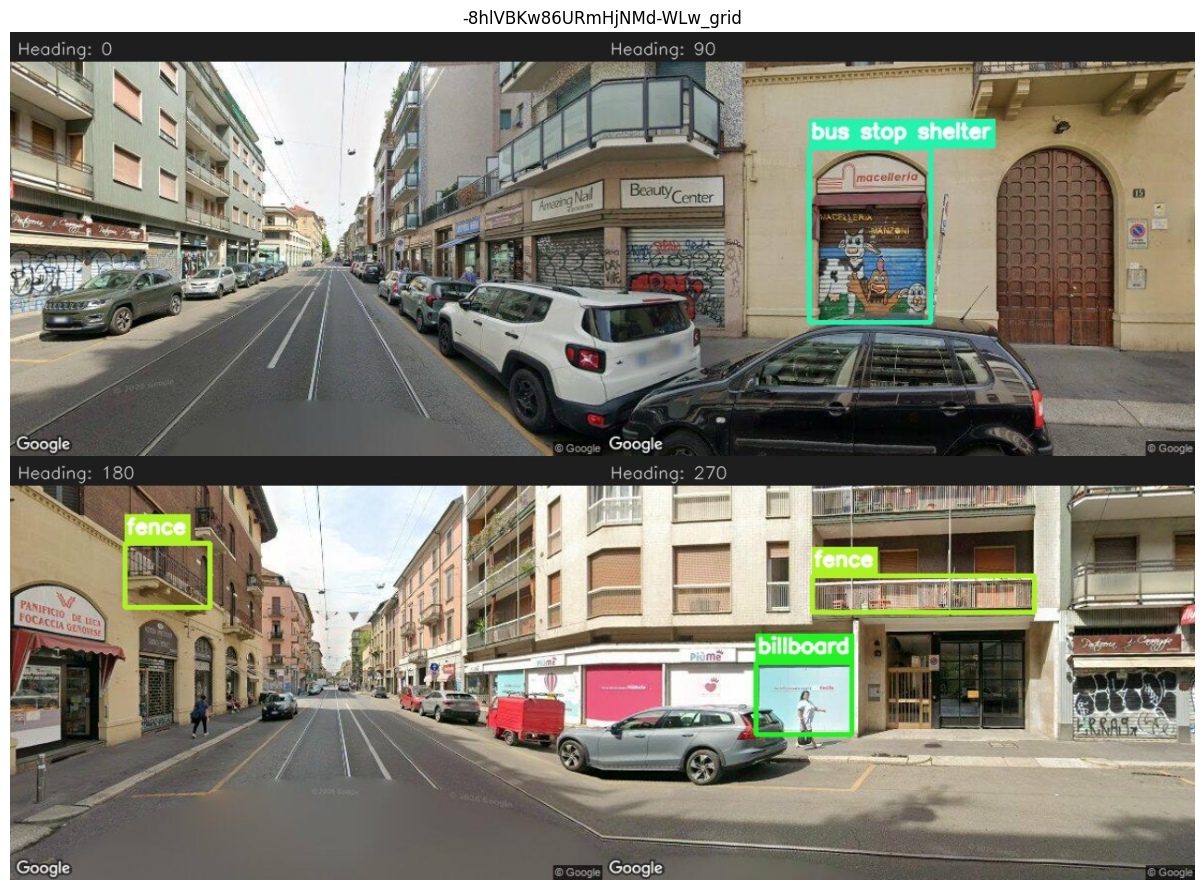


🏁 Riepilogo finale:
   Excel:              /content/drive/MyDrive/Polimi/StrategicVisionsBEFuture/ProgettoFinale_SVBEF/WIP/Prove/Outputs_ProvaFinale/gsv_detection_results ProvaFinale.xlsx
   Annotate salvate:   452
   Griglie salvate:    113
   Checkpoint:         /content/drive/MyDrive/Polimi/StrategicVisionsBEFuture/ProgettoFinale_SVBEF/WIP/Prove/Outputs_ProvaFinale/gdino_checkpoint.json

ℹ️  Il file gdino_checkpoint.json su Drive può essere eliminato
   solo quando sei sicuro che l'elaborazione è completa e l'Excel è corretto.


In [ ]:
from IPython.display import display as ipy_display
import matplotlib.pyplot as plt
import matplotlib.image as mpimg

df = pd.DataFrame(records)

print('📊 Prime 20 righe del risultato:')
BASE_COLS = ['Latitudine', 'Longitudine', 'PANO_ID', 'Orientamento']
ALL_COLS  = BASE_COLS + CLASSES
ipy_display(df[ALL_COLS].head(20))

totals_mask = [r.get('_tipo') == 'totale' for r in records]
df_totals   = df[totals_mask][CLASSES] if any(totals_mask) else pd.DataFrame()

if not df_totals.empty:
    print('\n📈 Statistiche per PANO ID (righe TOTALE):')
    ipy_display(df_totals.describe().round(2))
    print('\n🔝 Classi più rilevate (somma su tutti i punti):')
    ipy_display(df_totals.sum().sort_values(ascending=False).rename('Totale rilevamenti'))

grid_files = sorted(Path(ANNOTATED_FOLDER).glob('*_grid.jpg'))
if grid_files:
    print(f'\n🖼️  Anteprima prima griglia ({grid_files[0].name}):')
    img = cv2.imread(str(grid_files[0]))
    plt.figure(figsize=(16,9))
    plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
    plt.axis('off')
    plt.title(grid_files[0].stem, fontsize=12)
    plt.tight_layout()
    plt.show()

ann_count  = len(list(Path(ANNOTATED_FOLDER).glob('*_annotated.jpg')))
grid_count = len(list(Path(ANNOTATED_FOLDER).glob('*_grid.jpg')))
print(f'\n🏁 Riepilogo finale:')
print(f'   Excel:              {output_excel_path}')
print(f'   Annotate salvate:   {ann_count}')
print(f'   Griglie salvate:    {grid_count}')
print(f'   Checkpoint:         {CHECKPOINT_PATH}')
print()
print('ℹ️  Il file gdino_checkpoint.json su Drive può essere eliminato')
print('   solo quando sei sicuro che l\'elaborazione è completa e l\'Excel è corretto.')